# 03 — Model training


No target leakage: the features do not include `phenotype_group` and `clinvar_class_simple`, which are used to form the target label. Likely-inclusive labeling scheme: `benign+likely_benign` vs `pathogenic+likely_pathogenic`.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, f1_score

from scipy.stats import loguniform
import joblib
from IPython.display import display

PROCESSED = Path('../data/processed')
FIGURES = Path('../figures')
MODELS = Path('../models')

FIGURES.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED / 'DMD_variants_annotated.csv')
print('Loaded:', PROCESSED / 'DMD_variants_annotated.csv')
print('Shape:', df.shape)


Loaded: ../data/processed/DMD_variants_annotated.csv
Shape: (11308, 29)


## 1. Dataset preparation and 50/50 balancing


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = None
for rel in ('../..', '..', '.'):
    cand = (Path.cwd() / rel).resolve()
    if (cand / 'src' / 'utils.py').exists():
        PROJECT_ROOT = cand
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('project root with src/utils.py not found')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import ensure_column, normalize_cat


def _normalized_key_token(series, uppercase=False):
    out = series.astype('string').str.strip()
    out = out.replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA, 'none': pd.NA, '<NA>': pd.NA})
    if uppercase:
        out = out.str.upper()
    return out


def build_variant_group_id(data):
    tmp = data.copy()
    for col in ['chr', 'pos', 'ref', 'alt', 'var_id', 'rsid']:
        ensure_column(tmp, col)

    chr_key = _normalized_key_token(tmp['chr'], uppercase=True).str.replace('^CHR', '', regex=True)
    pos_key = pd.to_numeric(tmp['pos'], errors='coerce').round().astype('Int64').astype('string')
    ref_key = _normalized_key_token(tmp['ref'], uppercase=True)
    alt_key = _normalized_key_token(tmp['alt'], uppercase=True)
    var_id_key = _normalized_key_token(tmp['var_id'])
    rsid_key = _normalized_key_token(tmp['rsid'], uppercase=True)

    group_id = pd.Series(pd.NA, index=tmp.index, dtype='string')

    has_cpra = chr_key.notna() & pos_key.notna() & ref_key.notna() & alt_key.notna()
    group_id.loc[has_cpra] = (
        'CPRA:'
        + chr_key.loc[has_cpra]
        + ':'
        + pos_key.loc[has_cpra]
        + ':'
        + ref_key.loc[has_cpra]
        + '>'
        + alt_key.loc[has_cpra]
    )

    missing = group_id.isna()
    has_cpos = missing & chr_key.notna() & pos_key.notna()
    group_id.loc[has_cpos] = 'CPOS:' + chr_key.loc[has_cpos] + ':' + pos_key.loc[has_cpos]

    missing = group_id.isna()
    group_id.loc[missing & var_id_key.notna()] = 'VARID:' + var_id_key.loc[missing & var_id_key.notna()]

    missing = group_id.isna()
    group_id.loc[missing & rsid_key.notna()] = 'RSID:' + rsid_key.loc[missing & rsid_key.notna()]

    missing = group_id.isna()
    group_id.loc[missing] = pd.Series(tmp.index[missing], index=tmp.index[missing]).map(lambda x: f'ROW:{x}')

    return group_id.astype(str)


def deduplicate_training_pool(data):
    tmp = data.copy()
    tmp['group_id'] = build_variant_group_id(tmp)

    group_summary = tmp.groupby('group_id')['is_pathogenic'].agg(['size', 'nunique'])
    conflict_groups = group_summary[group_summary['nunique'] > 1].index

    n_conflict_groups = int(len(conflict_groups))
    n_conflict_rows = int(tmp['group_id'].isin(conflict_groups).sum())

    tmp = tmp.loc[~tmp['group_id'].isin(conflict_groups)].copy()
    n_before_dedup = len(tmp)
    tmp = tmp.drop_duplicates(subset=['group_id'], keep='first').reset_index(drop=True)
    n_after_dedup = len(tmp)

    report = {
        'n_conflict_groups_removed': n_conflict_groups,
        'n_conflict_rows_removed': n_conflict_rows,
        'n_same_label_duplicates_collapsed': int(n_before_dedup - n_after_dedup)
    }
    return tmp, report


work = df.copy()
for col in ['clinvar_class_simple', 'mutation_type_group', 'domain', 'frame_status', 'clinvar_consequence', 'var_type', 'rsid']:
    ensure_column(work, col)
    work[col] = work[col].apply(normalize_cat)

for col in ['exon', 'interval_length', 'aa_pos', 'revel', 'meta_lr', 'allele_freq', 'hemizygote_count', 'homozygote_count', 'pos']:
    ensure_column(work, col)
    work[col + '_num'] = pd.to_numeric(work[col], errors='coerce')

work['frame_bin'] = work['frame_status'].map({'in-frame': 0, 'out-of-frame': 1})
work['rsid_missing'] = work['rsid'].isna().astype(float)

work['target_class'] = pd.Series(np.nan, index=work.index, dtype='object')
work.loc[work['clinvar_class_simple'].isin(['pathogenic', 'likely_pathogenic']), 'target_class'] = 'pathogenic'
work.loc[work['target_class'].isna() & work['clinvar_class_simple'].isin(['benign', 'likely_benign']), 'target_class'] = 'benign'

full_df = work.loc[work['target_class'].notna()].copy()
full_df['is_pathogenic'] = (full_df['target_class'] == 'pathogenic').astype(int)

dedup_df, dedup_report = deduplicate_training_pool(full_df)

path_df = dedup_df[dedup_df['is_pathogenic'] == 1]
ben_df = dedup_df[dedup_df['is_pathogenic'] == 0]
min_n = min(len(path_df), len(ben_df))

model_df = pd.concat([
    path_df.sample(n=min_n, random_state=42),
    ben_df.sample(n=min_n, random_state=42)
], ignore_index=True).sample(frac=1.0, random_state=42).reset_index(drop=True)

print('Full candidate rows:', len(full_df))
print('Rows after dedup:', len(dedup_df))
print('Conflict groups removed:', dedup_report['n_conflict_groups_removed'])
print('Conflict rows removed:', dedup_report['n_conflict_rows_removed'])
print('Same-label duplicates collapsed:', dedup_report['n_same_label_duplicates_collapsed'])
print('Full class detail:')
print(full_df['target_class'].value_counts(dropna=False))
print()
print('Balanced rows (50/50):', len(model_df))
print('Balanced class labels:')
print(model_df['is_pathogenic'].value_counts(dropna=False))


Full candidate rows: 7120
Rows after dedup: 5688
Conflict groups removed: 101
Conflict rows removed: 235
Same-label duplicates collapsed: 1197
Full class detail:
target_class
benign        3702
pathogenic    3418
Name: count, dtype: int64

Balanced rows (50/50): 4490
Balanced class labels:
is_pathogenic
1    2245
0    2245
Name: count, dtype: int64


## 2. Feature engineering (no leakage features)


In [3]:
feat = model_df.copy()

feat['domain_clean'] = feat['domain'].fillna('Missing_domain')
feat['mutation_type_clean'] = feat['mutation_type_group'].fillna('Missing_mutation')
feat['consequence_clean'] = feat['clinvar_consequence'].fillna('Missing_consequence')
feat['var_type_clean'] = feat['var_type'].fillna('Missing_var_type')

feat['exon_num'] = feat['exon_num']
feat['is_distal'] = feat['exon_num'].ge(45).astype(float)
feat['is_hotspot_distal'] = feat['exon_num'].between(45, 55, inclusive='both').astype(float)
feat['is_hotspot_proximal'] = feat['exon_num'].between(3, 9, inclusive='both').astype(float)
feat['exon_bin'] = pd.cut(feat['exon_num'], bins=[0, 9, 44, 55, 79], include_lowest=True)
feat['exon_bin'] = feat['exon_bin'].astype(str).replace('nan', 'Missing_exon_bin')

feat['domain_group'] = np.where(
    feat['domain_clean'].str.contains('spectrin', case=False, na=False),
    'rod',
    np.where(
        feat['domain_clean'].str.contains('interaction|actin|binding|ch1|ch2|ww|cysteine', case=False, regex=True, na=False),
        'binding',
        np.where(feat['domain_clean'].str.contains('disordered', case=False, na=False), 'disordered', 'other_domain')
    )
)

feat['mut_is_splice'] = feat['mutation_type_clean'].str.contains('splice', case=False, na=False).astype(float)
feat['mut_is_nonsense'] = feat['mutation_type_clean'].str.contains('nonsense', case=False, na=False).astype(float)
feat['mut_is_frameshift'] = feat['mutation_type_clean'].str.contains('frameshift', case=False, na=False).astype(float)
feat['mut_is_large'] = feat['mutation_type_clean'].str.contains('large', case=False, na=False).astype(float)

feat['log_interval_length'] = np.log1p(feat['interval_length_num'])
feat['log_allele_freq'] = np.log1p(feat['allele_freq_num'])
feat['log_hemizygote'] = np.log1p(feat['hemizygote_count_num'])
feat['log_homozygote'] = np.log1p(feat['homozygote_count_num'])

feat['missing_domain'] = feat['domain'].isna().astype(float)
feat['missing_revel'] = feat['revel_num'].isna().astype(float)
feat['missing_meta_lr'] = feat['meta_lr_num'].isna().astype(float)
feat['missing_af'] = feat['allele_freq_num'].isna().astype(float)
feat['missing_aa_pos'] = feat['aa_pos_num'].isna().astype(float)

features = [
    'exon_num', 'frame_bin', 'domain_clean', 'mutation_type_clean',
    'consequence_clean', 'var_type_clean', 'domain_group', 'exon_bin',
    'interval_length_num', 'aa_pos_num', 'revel_num', 'meta_lr_num',
    'allele_freq_num', 'hemizygote_count_num', 'homozygote_count_num', 'pos_num',
    'log_interval_length', 'log_allele_freq', 'log_hemizygote', 'log_homozygote',
    'is_distal', 'is_hotspot_distal', 'is_hotspot_proximal',
    'mut_is_splice', 'mut_is_nonsense', 'mut_is_frameshift', 'mut_is_large',
    'missing_domain', 'missing_revel', 'missing_meta_lr', 'missing_af', 'missing_aa_pos',
    'rsid_missing'
]

y = feat['is_pathogenic'].astype(int)
X = feat[features].copy()

print('Feature set size:', len(features))
print('Dataset for training:', X.shape)


Feature set size: 33
Dataset for training: (4490, 33)


## 3. Train/test split


In [4]:
groups = feat['group_id'].astype(str)
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train target mean:', round(float(y_train.mean()), 4), 'Test target mean:', round(float(y_test.mean()), 4))


Train shape: (3592, 33) Test shape: (898, 33)
Train target mean: 0.5047 Test target mean: 0.4811


## 4. Hyperparameter tuning with cross-validation


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc': 'roc_auc'
}

lr_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=8000, solver='saga', random_state=42))
])

lr_param_dist = {
    'model__C': loguniform(1e-3, 1e2),
    'model__penalty': ['l1', 'l2'],
    'model__class_weight': [None, 'balanced']
}

lr_search = RandomizedSearchCV(
    estimator=lr_pipe,
    param_distributions=lr_param_dist,
    n_iter=16,
    scoring=scoring,
    refit='accuracy',
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=0
)

rf_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    'model__n_estimators': [300, 500, 700, 1000, 1200],
    'model__max_depth': [8, 12, 16, 24, 32, None],
    'model__min_samples_split': [2, 4, 6, 8, 10],
    'model__min_samples_leaf': [1, 2, 3, 4],
    'model__max_features': ['sqrt', 0.3, 0.5, 0.7],
    'model__bootstrap': [True, False],
    'model__class_weight': [None, 'balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=24,
    scoring=scoring,
    refit='accuracy',
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=0
)

lr_search.fit(X_train, y_train)
rf_search.fit(X_train, y_train)

print('Best LR CV accuracy:', lr_search.best_score_)
print('Best LR params:', lr_search.best_params_)
print()
print('Best RF CV accuracy:', rf_search.best_score_)
print('Best RF params:', rf_search.best_params_)


Best LR CV accuracy: 0.9810716679386798
Best LR params: {'model__C': np.float64(14.528246637516036), 'model__class_weight': 'balanced', 'model__penalty': 'l2'}

Best RF CV accuracy: 0.9816279961723378
Best RF params: {'model__n_estimators': 500, 'model__min_samples_split': 6, 'model__min_samples_leaf': 1, 'model__max_features': 0.3, 'model__max_depth': 12, 'model__class_weight': 'balanced_subsample', 'model__bootstrap': True}


## 5. Compare tuned models on test set


In [6]:
candidates = {
    'LogReg_tuned': lr_search.best_estimator_,
    'RandomForest_tuned': rf_search.best_estimator_
}

rows = []
pred_store = {}
for name, model in candidates.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    pred_store[name] = {'proba': y_proba, 'pred': y_pred}
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(rows).sort_values(['accuracy', 'auc'], ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]['model']
best_model = candidates[best_model_name]
print('Best test model:', best_model_name)


,model,accuracy,balanced_accuracy,f1,auc
0,LogReg_tuned,0.983296,0.982892,0.982456,0.995067
1,RandomForest_tuned,0.983296,0.982892,0.982456,0.993907


Best test model: LogReg_tuned


## 6. ROC and confusion matrix


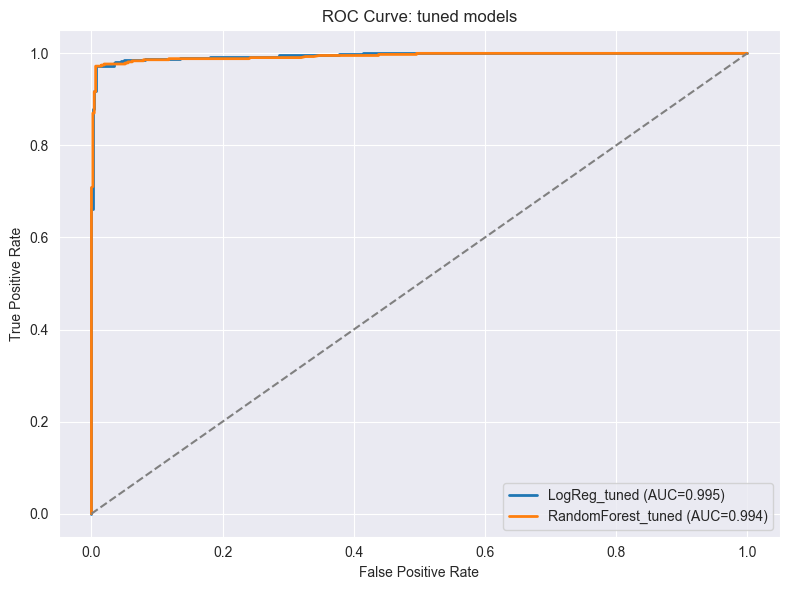

Best model AUC: 0.9950673581306628
Best model accuracy: 0.9832962138084632
Best model balanced accuracy: 0.9828922269909395

Classification report:
              precision    recall  f1-score   support

           0      0.975     0.994     0.984       466
           1      0.993     0.972     0.982       432

    accuracy                          0.983       898
   macro avg      0.984     0.983     0.983       898
weighted avg      0.983     0.983     0.983       898



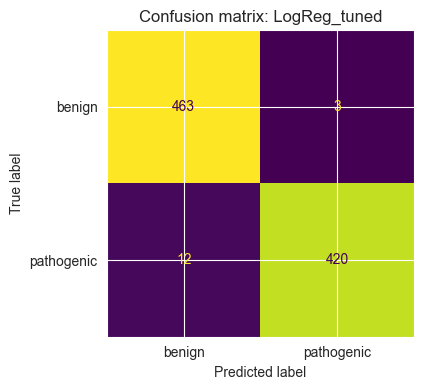

In [7]:
plt.figure(figsize=(8, 6))
for name, vals in pred_store.items():
    fpr, tpr, _ = roc_curve(y_test, vals['proba'])
    auc = roc_auc_score(y_test, vals['proba'])
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: tuned models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_pred = pred_store[best_model_name]['pred']
best_proba = pred_store[best_model_name]['proba']

print('Best model AUC:', roc_auc_score(y_test, best_proba))
print('Best model accuracy:', accuracy_score(y_test, best_pred))
print('Best model balanced accuracy:', balanced_accuracy_score(y_test, best_pred))
print()
print('Classification report:')
print(classification_report(y_test, best_pred, digits=3))

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['benign', 'pathogenic']).plot(ax=ax, colorbar=False)
plt.title(f'Confusion matrix: {best_model_name}')
plt.tight_layout()
plt.show()


## 7. Validation demonstration (leakage checks, baseline, permutation, CI)


,model,split,accuracy,balanced_accuracy,f1,auc
0,LogReg_tuned,train,0.983296,0.983374,0.983315,0.997341
1,LogReg_tuned,test,0.983296,0.982892,0.982456,0.995067
2,RandomForest_tuned,train,0.987472,0.987537,0.987503,0.999464
3,RandomForest_tuned,test,0.983296,0.982892,0.982456,0.993907


Group overlap train/test: 0


,model,accuracy,balanced_accuracy,f1,auc
0,Dummy_most_frequent,0.481069,0.500000,0.649624,0.500000
1,Dummy_stratified,0.474388,0.474562,0.467269,0.474562


,iteration,accuracy,auc
0,1,0.416481,0.438995
1,2,0.525612,0.528856
2,3,0.366370,0.378482
3,4,0.552339,0.554815
4,5,0.500000,0.490244
5,6,0.446548,0.458949
6,7,0.520045,0.516725
7,8,0.474388,0.475133
8,9,0.593541,0.610724
9,10,0.493318,0.497223


Permutation p-value (AUC): 0.090909
Permutation p-value (accuracy): 0.090909


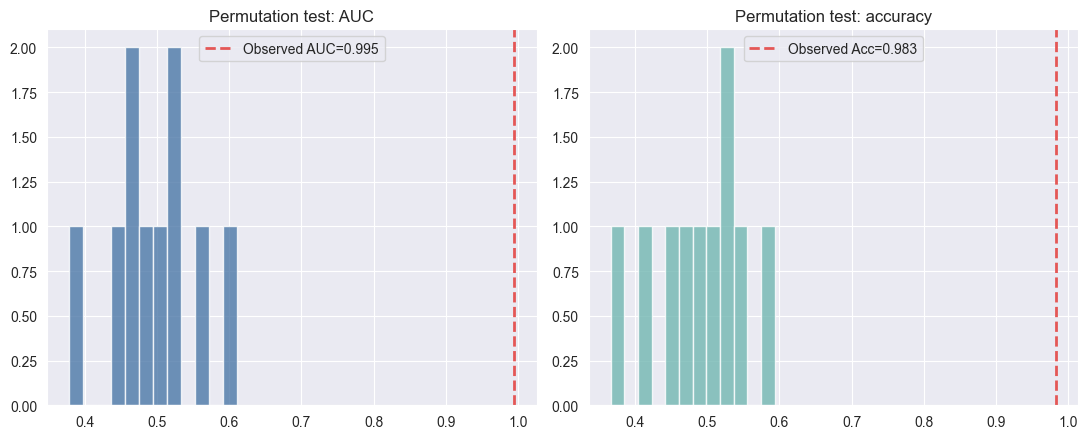

95% CI AUC: [0.9911, 0.9978]
95% CI accuracy: [0.9749, 0.9911]


In [8]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier


def compute_metrics(y_true, y_proba):
    y_pred = (y_proba >= 0.5).astype(int)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_proba),
    }


# 1) Train vs test metrics for both models
val_rows = []
for name, model in candidates.items():
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    val_rows.append({'model': name, 'split': 'train', **compute_metrics(y_train, train_proba)})
    val_rows.append({'model': name, 'split': 'test', **compute_metrics(y_test, test_proba)})

validation_train_test_df = pd.DataFrame(val_rows)
display(validation_train_test_df)


# 2) Group leakage check
train_groups = set(groups.iloc[train_idx].astype(str))
test_groups = set(groups.iloc[test_idx].astype(str))
group_overlap_count = len(train_groups & test_groups)
print('Group overlap train/test:', group_overlap_count)


# 3) Dummy baselines on the same split
baseline_rows = []
for strategy in ['most_frequent', 'stratified']:
    baseline = DummyClassifier(strategy=strategy, random_state=42)
    baseline.fit(X_train, y_train)
    base_proba = baseline.predict_proba(X_test)[:, 1]
    baseline_rows.append({'model': f'Dummy_{strategy}', **compute_metrics(y_test, base_proba)})

validation_baseline_df = pd.DataFrame(baseline_rows)
display(validation_baseline_df)


# 4) Permutation test for the best model
rng = np.random.default_rng(42)
observed_accuracy = accuracy_score(y_test, best_pred)
observed_auc = roc_auc_score(y_test, best_proba)

perm_rows = []
for i in range(10):
    perm_model = clone(best_model)
    y_perm = rng.permutation(y_train.to_numpy())
    perm_model.fit(X_train, y_perm)
    perm_proba = perm_model.predict_proba(X_test)[:, 1]
    perm_pred = (perm_proba >= 0.5).astype(int)
    perm_rows.append({
        'iteration': i + 1,
        'accuracy': accuracy_score(y_test, perm_pred),
        'auc': roc_auc_score(y_test, perm_proba),
    })

validation_perm_df = pd.DataFrame(perm_rows)
perm_auc_p = ((validation_perm_df['auc'] >= observed_auc).sum() + 1) / (len(validation_perm_df) + 1)
perm_acc_p = ((validation_perm_df['accuracy'] >= observed_accuracy).sum() + 1) / (len(validation_perm_df) + 1)

display(validation_perm_df.head(10))
print('Permutation p-value (AUC):', round(float(perm_auc_p), 6))
print('Permutation p-value (accuracy):', round(float(perm_acc_p), 6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(validation_perm_df['auc'], bins=12, color='#4C78A8', alpha=0.8)
axes[0].axvline(observed_auc, color='#E45756', linestyle='--', linewidth=2, label=f'Observed AUC={observed_auc:.3f}')
axes[0].set_title('Permutation test: AUC')
axes[0].legend()

axes[1].hist(validation_perm_df['accuracy'], bins=12, color='#72B7B2', alpha=0.8)
axes[1].axvline(observed_accuracy, color='#E45756', linestyle='--', linewidth=2, label=f'Observed Acc={observed_accuracy:.3f}')
axes[1].set_title('Permutation test: accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


# 5) Bootstrap CI for best model metrics
boot_rng = np.random.default_rng(42)
y_test_arr = y_test.to_numpy()
n = len(y_test_arr)
boot_auc = []
boot_acc = []
for _ in range(300):
    idx = boot_rng.integers(0, n, n)
    y_b = y_test_arr[idx]
    if np.unique(y_b).size < 2:
        continue
    p_b = best_proba[idx]
    pred_b = (p_b >= 0.5).astype(int)
    boot_auc.append(roc_auc_score(y_b, p_b))
    boot_acc.append(accuracy_score(y_b, pred_b))

auc_ci = (float(np.quantile(boot_auc, 0.025)), float(np.quantile(boot_auc, 0.975)))
acc_ci = (float(np.quantile(boot_acc, 0.025)), float(np.quantile(boot_acc, 0.975)))

print('95% CI AUC:', f'[{auc_ci[0]:.4f}, {auc_ci[1]:.4f}]')
print('95% CI accuracy:', f'[{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]')

validation_summary = {
    'group_overlap_count': int(group_overlap_count),
    'observed_accuracy': float(observed_accuracy),
    'observed_auc': float(observed_auc),
    'perm_auc_p_value': float(perm_auc_p),
    'perm_accuracy_p_value': float(perm_acc_p),
    'auc_ci_low': auc_ci[0],
    'auc_ci_high': auc_ci[1],
    'accuracy_ci_low': acc_ci[0],
    'accuracy_ci_high': acc_ci[1],
}



## 8. Feature importance of best model


,feature,importance
99,cat__consequence_clean_synonymous variant,4.932638
88,cat__consequence_clean_nonsense,4.725181
95,cat__consequence_clean_splice donor variant,3.198349
100,cat__consequence_clean_synonymous variant|5 pr...,3.148350
81,cat__consequence_clean_intron variant,2.934887
89,cat__consequence_clean_nonsense|5 prime UTR va...,2.564339
19,num__mut_is_frameshift,1.987222
93,cat__consequence_clean_splice acceptor variant,1.893096
24,num__missing_af,1.754011
12,num__log_hemizygote,1.610302


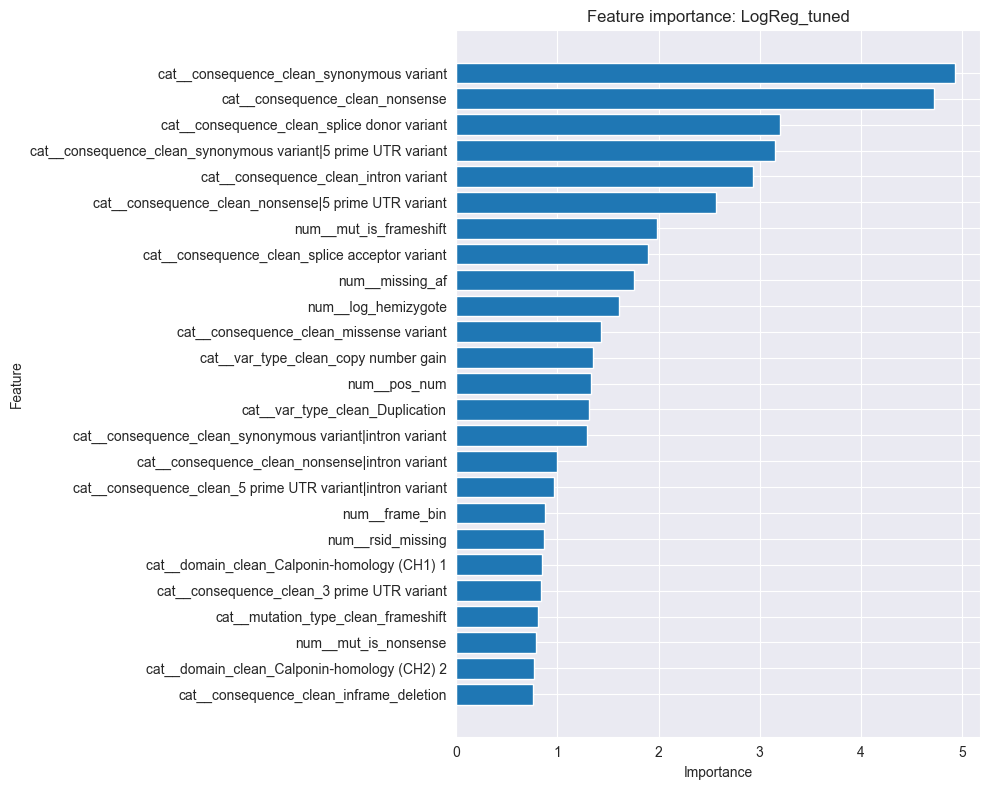

In [9]:
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

if 'LogReg' in best_model_name:
    importances = np.abs(best_model.named_steps['model'].coef_[0])
else:
    importances = best_model.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
display(imp_df.head(35))

plot_df = imp_df.head(25).iloc[::-1]
plt.figure(figsize=(10, 8))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Feature importance: {best_model_name}')
plt.tight_layout()
plt.show()


## 9. Save artifacts


In [10]:
model_best_path = MODELS / 'model.pkl'
model_logreg_path = MODELS / 'model_logreg.pkl'
model_rf_path = MODELS / 'model_random_forest.pkl'

joblib.dump(best_model, model_best_path)
joblib.dump(candidates['LogReg_tuned'], model_logreg_path)
joblib.dump(candidates['RandomForest_tuned'], model_rf_path)

print('Saved:', model_best_path)
print('Saved:', model_logreg_path)
print('Saved:', model_rf_path)


Saved: ../models/model.pkl
Saved: ../models/model_logreg.pkl
Saved: ../models/model_random_forest.pkl
